In [41]:
from preprocess import preprocess_data
from feature_engineering import create_features
from train import train_model 

In [42]:
google_path = r"C:\Users\aadit\OneDrive\Desktop\AIgnition\AIgnition\data\google_ads_campaign_stats.csv"
bing_path = r"C:\Users\aadit\OneDrive\Desktop\AIgnition\AIgnition\data\bing_campaign_stats.csv"

df = preprocess_data(google_path, bing_path)

print(df.head())

         Date           CampaignName CampaignType  campaign_budget      Spend  \
0  2025-02-21     Search_Campaign_01       SEARCH             50.0   0.000000   
1  2024-01-01  Search_TM_Campaign_01       SEARCH             90.0  46.980000   
2  2024-01-02  Search_TM_Campaign_01       SEARCH             90.0  53.558564   
3  2024-01-03  Search_TM_Campaign_01       SEARCH             90.0  75.700000   
4  2024-01-04  Search_TM_Campaign_01       SEARCH             90.0  95.300000   

   Impressions  Clicks  Conversions      Revenue  Source  
0            1       0     0.000000     0.000000  Google  
1          481     158     4.193582   549.988085  Google  
2          818     244     4.083258   670.816817  Google  
3         1079     357    10.356219   601.398431  Google  
4         1384     382    14.309580  1802.787630  Google  


In [43]:
df = create_features(df)

print(df.head())

   campaign_budget      Spend  Impressions  Clicks      Revenue  Year  Month  \
0             50.0   0.000000            1       0     0.000000  2025      2   
1             90.0  46.980000          481     158   549.988085  2024      1   
2             90.0  53.558564          818     244   670.816817  2024      1   
3             90.0  75.700000         1079     357   601.398431  2024      1   
4             90.0  95.300000         1384     382  1802.787630  2024      1   

   Day  DayOfWeek  Week  CampaignType_DEMAND_GEN  CampaignType_DISPLAY  \
0   21          4     8                        0                     0   
1    1          0     1                        0                     0   
2    2          1     1                        0                     0   
3    3          2     1                        0                     0   
4    4          3     1                        0                     0   

   CampaignType_PERFORMANCEMAX  CampaignType_SEARCH  CampaignType_SHOPPING

In [44]:
import sklearn
print(sklearn.__version__)

1.7.0


In [45]:
import sys
print(sys.version)

3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]


In [46]:
comparison, best_model, X, y, X_test, y_test, best_pred = train_model(df)

comparison


Training Linear Regression...
MAE : 289.72
RMSE: 695.07
R²  : 0.7596

Training Random Forest...
MAE : 227.66
RMSE: 557.31
R²  : 0.8454

Training XGBoost...
MAE : 236.65
RMSE: 731.30
R²  : 0.7339

Model Comparison
               Model         MAE        RMSE        R2
0  Linear Regression  289.721050  695.070597  0.759579
1      Random Forest  227.656889  557.311404  0.845435
2            XGBoost  236.648236  731.298740  0.733864

Best Model : Random Forest
Model Saved Successfully!


,Model,MAE,RMSE,R2
0,Linear Regression,289.721050,695.070597,0.759579
1,Random Forest,227.656889,557.311404,0.845435
2,XGBoost,236.648236,731.298740,0.733864


In [47]:
import os

print(os.path.exists("best_model.pkl"))
print(os.path.exists("feature_columns.pkl"))

True
False


In [58]:
import joblib

feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

print("Done")

Done


In [59]:
import os

print(os.path.exists("feature_columns.pkl"))

True


In [48]:
import os

print(os.getcwd())

print(os.listdir())

c:\Users\aadit\OneDrive\Desktop\Revenue_forecasting
['.vscode', 'app.py', 'best_model.pkl', 'feature_engineering.py', 'feature_importance.csv', 'forecast.ipynb', 'predict.py', 'preprocess.py', 'train.py', '__pycache__']


In [49]:
print(y.describe())

count    22131.000000
mean       426.492494
std       1508.921153
min          0.000000
25%          0.000000
50%         50.000000
75%        323.527453
max      72058.988368
Name: Revenue, dtype: float64


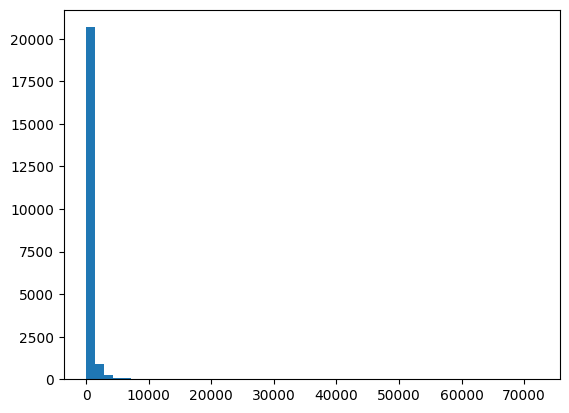

In [50]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50)
plt.show()

In [51]:
import pandas as pd
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                        Feature    Importance
3                        Clicks  5.611969e-01
1                         Spend  2.812457e-01
2                   Impressions  7.530824e-02
6                           Day  2.046475e-02
8                          Week  1.903168e-02
7                     DayOfWeek  1.331659e-02
0               campaign_budget  1.279383e-02
5                         Month  5.122736e-03
4                          Year  4.630006e-03
13        CampaignType_SHOPPING  2.760855e-03
11  CampaignType_PERFORMANCEMAX  2.191324e-03
12          CampaignType_SEARCH  9.637147e-04
15                Source_Google  7.297845e-04
9       CampaignType_DEMAND_GEN  1.912929e-04
14           CampaignType_VIDEO  5.259940e-05
10         CampaignType_DISPLAY  1.622920e-08


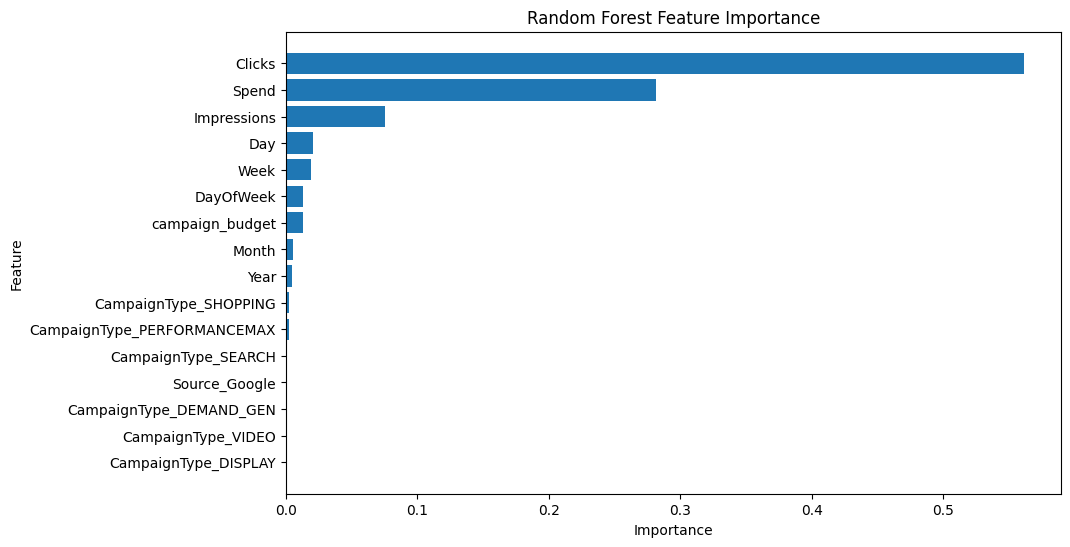

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [53]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

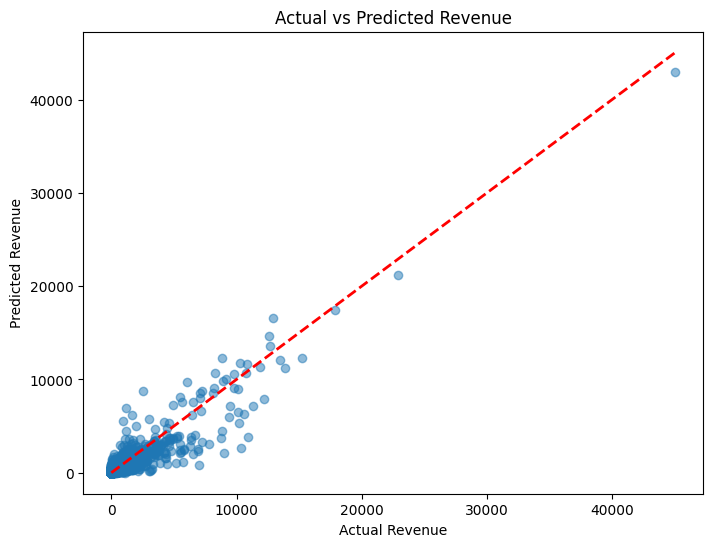

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, best_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

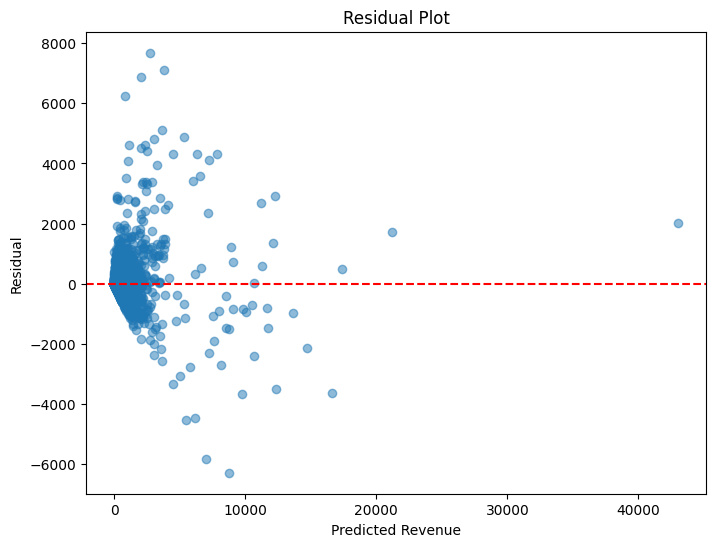

In [55]:
residuals = y_test - best_pred

plt.figure(figsize=(8,6))

plt.scatter(best_pred, residuals, alpha=0.5)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Revenue")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()